# k-Anonymity Impact on Model Performance
This notebook analyzes how different models behave under various levels of k-anonymity on the Banking dataset. It explores:
- Accuracy vs. k, LM, and MD
- F1-Score vs. k, LM, and MD
- Comparative robustness of models under increasing anonymity

# Banking Dataset Analysis

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Load the dataset
df_banking = pd.read_csv("../results/banking_model_results_2.csv")
df_banking.head()

,k,model,LM,MD,accuracy,f1_0,f1_1,macro_avg_f1,macro_avg_precision,macro_avg_recall,precision_0,precision_1,recall_0,recall_1,weighted_avg_f1,weighted_avg_precision,weighted_avg_recall
0,1,logistic,0.0000,0,0.721331,0.823998,0.331210,0.577604,0.580864,0.664276,0.931470,0.230258,0.738760,0.589792,0.766343,0.849431,0.721331
1,2,logistic,63042.4733,359903,0.671901,0.785668,0.300731,0.543199,0.564309,0.642026,0.928303,0.200314,0.681027,0.603025,0.728932,0.843131,0.671901
2,4,logistic,88947.0893,467508,0.656419,0.772797,0.295625,0.534211,0.561550,0.638999,0.928647,0.194453,0.661741,0.616257,0.716970,0.842749,0.656419
3,8,logistic,100511.1981,533745,0.639058,0.757756,0.292281,0.525018,0.559844,0.638187,0.930042,0.189645,0.639324,0.637051,0.703297,0.843418,0.639058
4,16,logistic,92905.6236,544369,0.568838,0.696599,0.255205,0.475902,0.539888,0.595965,0.919852,0.159923,0.560551,0.631380,0.644958,0.830943,0.568838


### Accuracy vs. k (Banking Dataset)

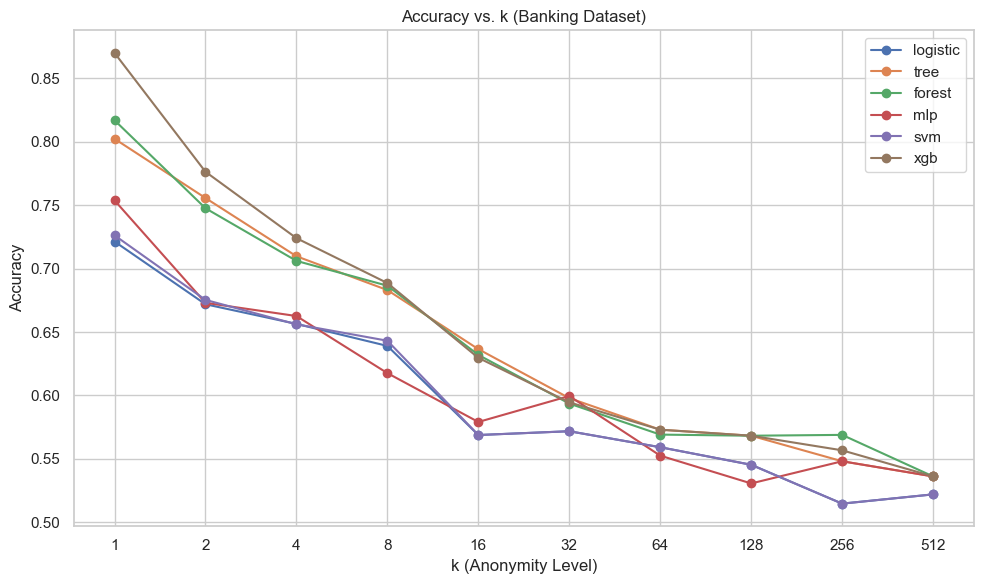

In [16]:
# Accuracy vs. k (log scale)
plt.figure(figsize=(10, 6))
for model in df_banking['model'].unique():
    subset = df_banking[df_banking['model'] == model]
    plt.plot(subset['k'], subset['accuracy'], marker='o', label=model)
plt.xscale('log', base=2)
plt.xticks(df_banking['k'].unique(), labels=df_banking['k'].unique())
plt.title('Accuracy vs. k (Banking Dataset)')
plt.xlabel('k (Anonymity Level)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Accuracy vs. LM (Banking Dataset)

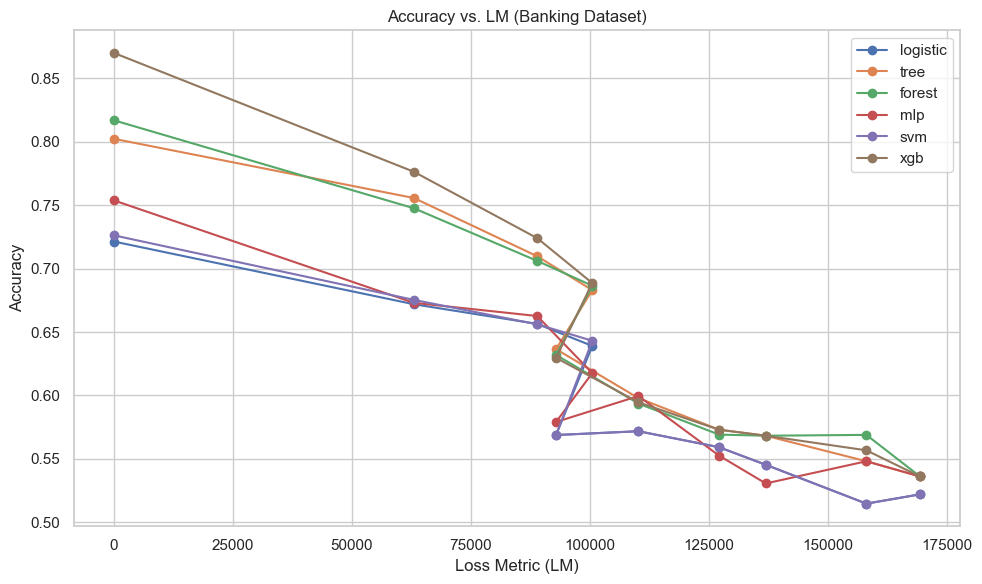

In [17]:
# Accuracy vs. LM
plt.figure(figsize=(10, 6))
for model in df_banking['model'].unique():
    subset = df_banking[df_banking['model'] == model]
    plt.plot(subset['LM'], subset['accuracy'], marker='o', label=model)
plt.title('Accuracy vs. LM (Banking Dataset)')
plt.xlabel('Loss Metric (LM)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Accuracy vs. MD (Banking Dataset)

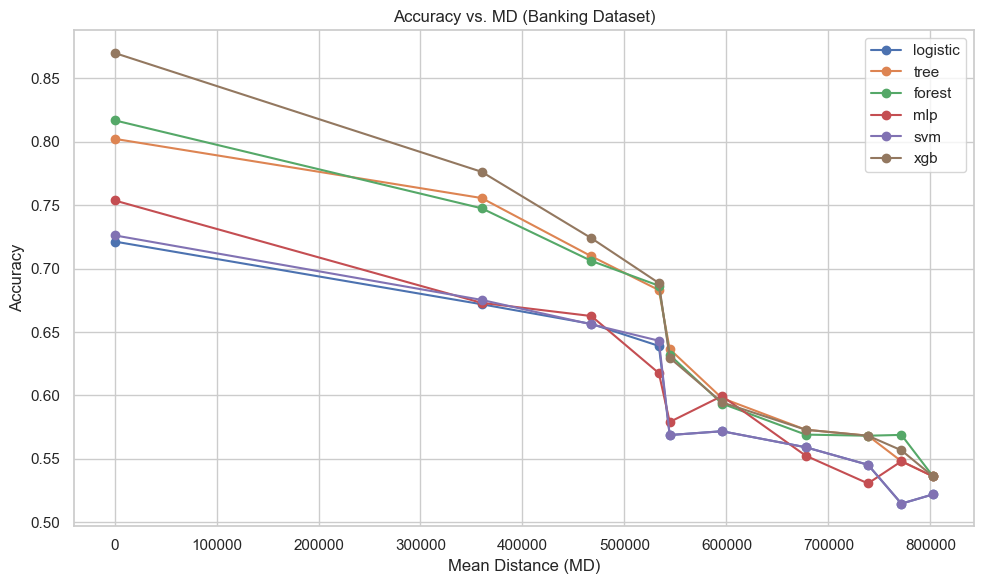

In [18]:
# Accuracy vs. MD
plt.figure(figsize=(10, 6))
for model in df_banking['model'].unique():
    subset = df_banking[df_banking['model'] == model]
    plt.plot(subset['MD'], subset['accuracy'], marker='o', label=model)
plt.title('Accuracy vs. MD (Banking Dataset)')
plt.xlabel('Mean Distance (MD)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Macro F1-Score vs. k (Banking Dataset)

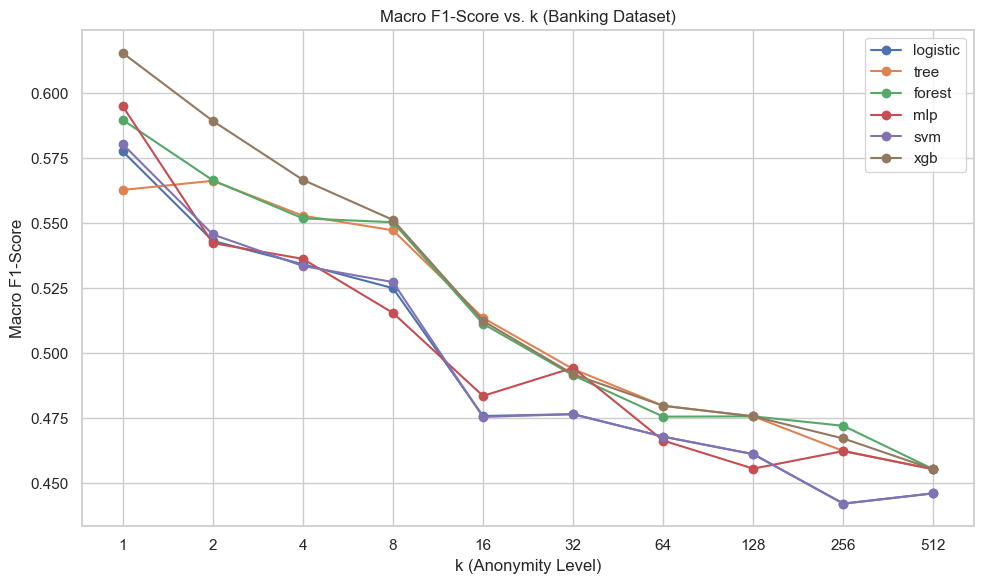

In [23]:
# Macro F1-Score vs. k
plt.figure(figsize=(10, 6))
for model in df_banking['model'].unique():
    subset = df_banking[df_banking['model'] == model]
    plt.plot(subset['k'], subset['macro_avg_f1'], marker='o', label=model)
plt.xscale('log', base=2)
plt.xticks(df_banking['k'].unique(), labels=df_banking['k'].unique())
plt.title('Macro F1-Score vs. k (Banking Dataset)')
plt.xlabel('k (Anonymity Level)')
plt.ylabel('Macro F1-Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Macro F1-Score vs. LM (Banking Dataset)

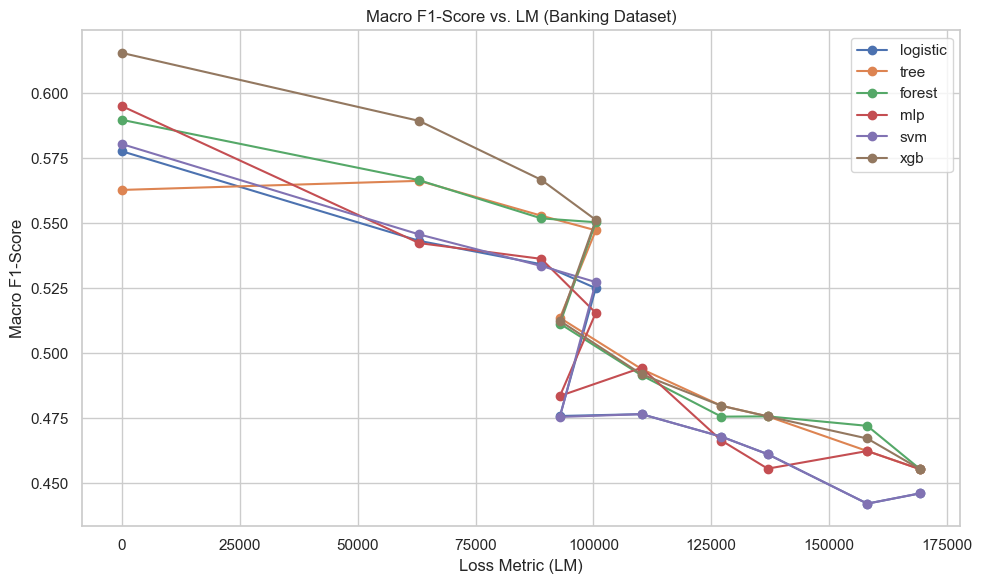

In [20]:
# Macro F1-Score vs. LM
plt.figure(figsize=(10, 6))
for model in df_banking['model'].unique():
    subset = df_banking[df_banking['model'] == model]
    plt.plot(subset['LM'], subset['macro_avg_f1'], marker='o', label=model)
plt.title('Macro F1-Score vs. LM (Banking Dataset)')
plt.xlabel('Loss Metric (LM)')
plt.ylabel('Macro F1-Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Macro F1-Score vs. MD (Banking Dataset)

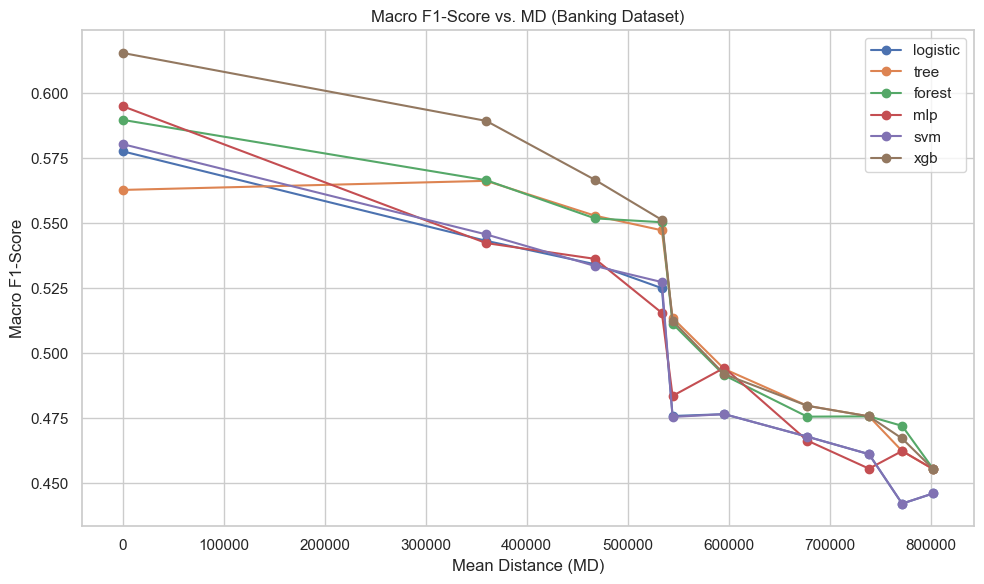

In [21]:
# Macro F1-Score vs. MD
plt.figure(figsize=(10, 6))
for model in df_banking['model'].unique():
    subset = df_banking[df_banking['model'] == model]
    plt.plot(subset['MD'], subset['macro_avg_f1'], marker='o', label=model)
plt.title('Macro F1-Score vs. MD (Banking Dataset)')
plt.xlabel('Mean Distance (MD)')
plt.ylabel('Macro F1-Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Percentage Change in Accuracy From Previous k Level

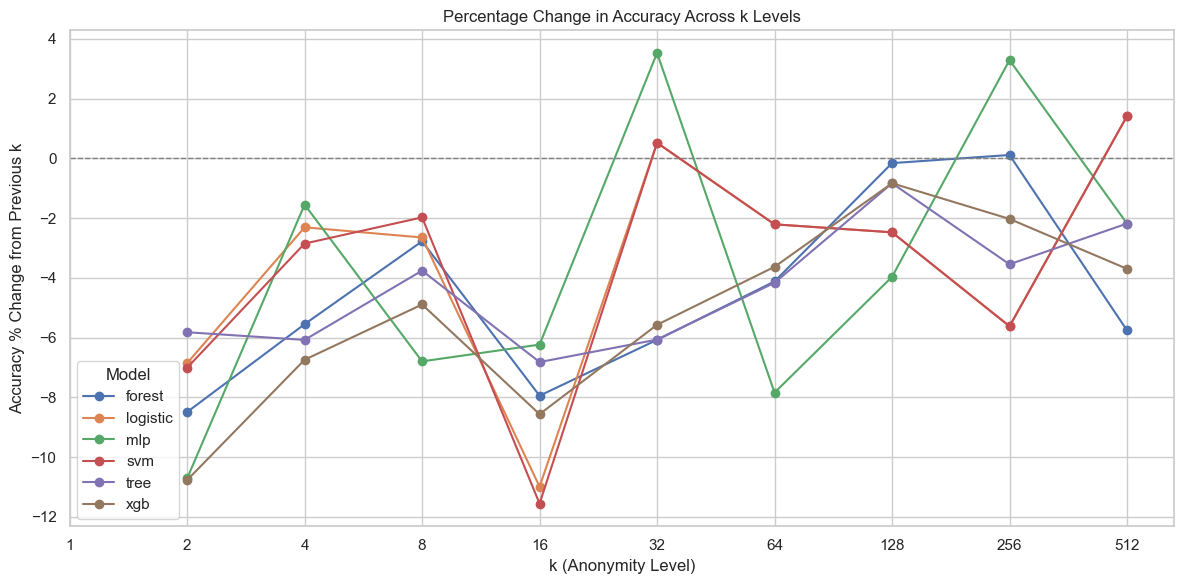

In [24]:
# Compute and plot percentage change in accuracy with respect to previous k level
df_sorted = df_banking.sort_values(by=["model", "k"])
df_sorted['accuracy_pct_change'] = df_sorted.groupby('model')['accuracy'].pct_change() * 100

# Plot percentage change for each model
plt.figure(figsize=(12, 6))
for model in df_sorted['model'].unique():
    subset = df_sorted[df_sorted['model'] == model]
    plt.plot(subset['k'], subset['accuracy_pct_change'], marker='o', label=model)

plt.xscale('log', base=2)
plt.xticks(df_banking['k'].unique(), labels=df_banking['k'].unique())
plt.axhline(0, linestyle='--', color='gray', linewidth=1)
plt.title('Percentage Change in Accuracy Across k Levels')
plt.xlabel('k (Anonymity Level)')
plt.ylabel('Accuracy % Change from Previous k')
plt.legend(title='Model')
plt.grid(True)
plt.tight_layout()
plt.show()

### Model Robustness Comparison

### Accuracy

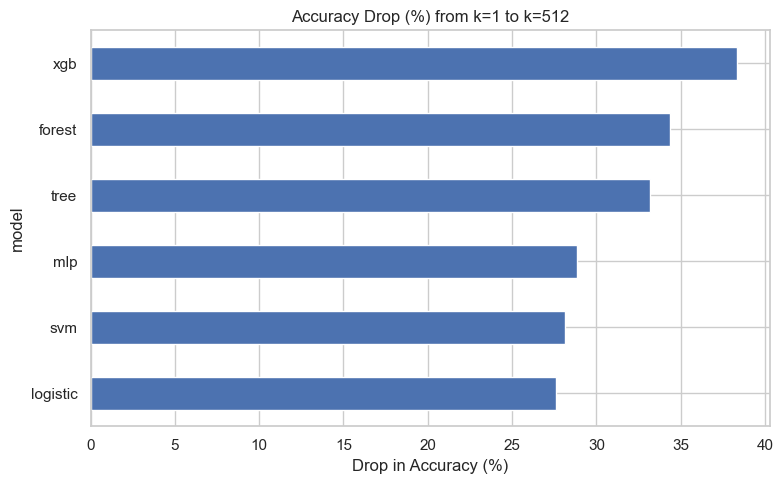

In [28]:
# Robustness analysis: accuracy decline rate from k=1 to k=1024
robustness = df_banking[df_banking['k'] == 1][['model', 'accuracy']].set_index('model')
robustness.columns = ['acc_k1']
f1_k512 = df_banking[df_banking['k'] == 512][['model', 'accuracy']].set_index('model')
f1_k512.columns = ['acc_k512']
robustness = robustness.join(f1_k512)
robustness['drop (%)'] = (robustness['acc_k1'] - robustness['acc_k512']) / robustness['acc_k1'] * 100
robustness.sort_values('drop (%)', inplace=True)
robustness.plot(kind='barh', y='drop (%)', legend=False, figsize=(8, 5), title='Accuracy Drop (%) from k=1 to k=512')
plt.xlabel('Drop in Accuracy (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Macro-F1

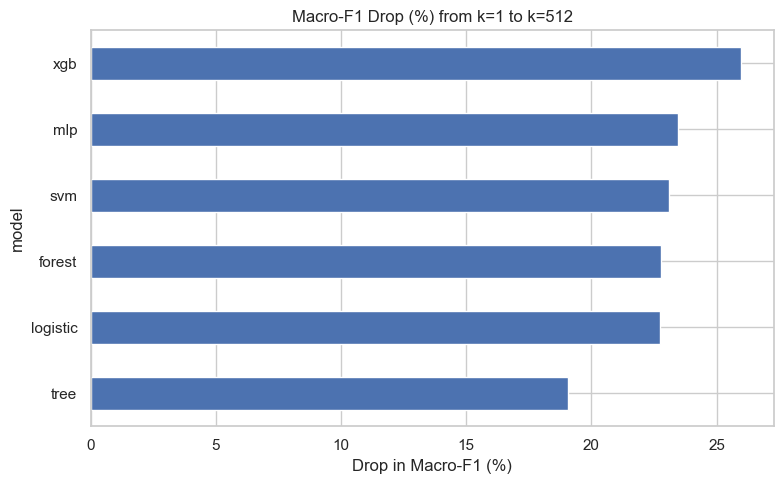

In [29]:
# Robustness analysis: macro-f1 decline rate from k=1 to k=1024
robustness = df_banking[df_banking['k'] == 1][['model', 'macro_avg_f1']].set_index('model')
robustness.columns = ['f1_k1']
f1_k512 = df_banking[df_banking['k'] == 512][['model', 'macro_avg_f1']].set_index('model')
f1_k512.columns = ['f1_k512']
robustness = robustness.join(f1_k512)
robustness['drop (%)'] = (robustness['f1_k1'] - robustness['f1_k512']) / robustness['f1_k1'] * 100
robustness.sort_values('drop (%)', inplace=True)
robustness.plot(kind='barh', y='drop (%)', legend=False, figsize=(8, 5), title='Macro-F1 Drop (%) from k=1 to k=512')
plt.xlabel('Drop in Macro-F1 (%)')
plt.grid(True)
plt.tight_layout()
plt.show()